# 2주차 (a) — 변수 선정 정량 검증 (상관·VIF·Granger)

> 계획서 v5.1 §3.2(a) 안전장치 — 산출물 3건을 2주차 끝까지 사전 마감
>
> **2주차 작업은 두 노트북으로 분할**:
> - `02_feature_selection.ipynb` (본 노트북) — 산출물 3건 (상관·VIF·Granger)
> - `02b_preprocess_baseline.ipynb` — 전처리 + Lag/Rolling + Naive·ARIMA + 누수 리뷰 + 리포트 골격

## 본 노트북의 목표

1. **상관 행렬 heatmap** — 22 변수 전체 + 9 freeze 부분
2. **VIF 표** — 9 freeze 변수의 다중공선성 정량 측정
3. **ADF/KPSS 정상성 + 차분 Granger 인과성** — 시간순 인과 가능성 검증
4. **종합 freeze 검증** — 1주차 결정 9개가 데이터로 정당화되는가
5. **산출물 정리** — `docs/feature_validation_w2.md` + 3개 figure

## 후속 단계

- **2주차 (b)** (`02b_preprocess_baseline.ipynb`): 전처리 파이프라인 + Lag/Rolling + Naive·ARIMA + 누수 코드 리뷰 + 리포트 골격
- **3주차** (`03_freeze_xgboost.ipynb`): 변수 freeze 최종 확정 + 5주차 ablation 대상 사전 명시 + XGBoost 분위수 회귀

## 1주차 freeze 9개 (옵션 C+) 복기

| 카테고리 | 변수 | 비고 |
|---------|------|------|
| 한국 (2) | `kr_treasury_3y`, `kr_base_rate` | 단기 금리 + 정책 |
| 미국 (3) | `us_treasury_10y`, `us_fed_funds`, `us_breakeven_10y` | 동조성 + 정책 + 인플레 |
| 위험 (2) | `vix`, `kospi` | 글로벌 + 국내 |
| 글로벌 (2) | `sp500`, `dxy` | 위험자산 + 달러 |

---

## 0. 환경 설정

In [2]:
# === 의존성 자동 체크 ===
import importlib.util, subprocess, sys

REQUIRED = {
    'statsmodels': 'statsmodels',
    'matplotlib':  'matplotlib',
    'seaborn':     'seaborn',
    'sklearn':     'scikit-learn',
}
for _import_name, _pip_name in REQUIRED.items():
    if importlib.util.find_spec(_import_name) is None:
        print(f'  Installing {_pip_name} ...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', _pip_name])
print('✅ 의존성 체크 완료\n')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / 'data'
FIG_DIR = PROJECT_ROOT / 'reports' / 'figures'
DOCS_DIR = PROJECT_ROOT / 'docs'
FIG_DIR.mkdir(parents=True, exist_ok=True)
DOCS_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 180)

print(f'PROJECT_ROOT: {PROJECT_ROOT}')

✅ 의존성 체크 완료

PROJECT_ROOT: c:\Users\dongs\Desktop\머신러닝 기말 팀플\macro-bond-forecast


---

## 1. 1주차 산출물 로드

In [3]:
wide_filled = pd.read_csv(
    DATA_DIR / 'interim' / 'wide_daily_filled.csv',
    index_col='date', parse_dates=['date']
)
features_v1 = pd.read_csv(
    DATA_DIR / 'processed' / 'features_v1_candidate.csv',
    index_col='date', parse_dates=['date']
)
dd = pd.read_csv(DATA_DIR / 'raw' / 'data_dictionary.csv')

TARGET = 'kr_treasury_10y'
FREEZE_FEATURES = [c for c in features_v1.columns if c != TARGET]

print(f'wide_filled.shape: {wide_filled.shape}  (광역 22 + 환율 + 타겟)')
print(f'features_v1.shape: {features_v1.shape}  (1주차 freeze 9 + 타겟)')
print(f'\n1주차 freeze 9개:')
for var in FREEZE_FEATURES:
    print(f'  - {var}')

wide_filled.shape: (4174, 24)  (광역 22 + 환율 + 타겟)
features_v1.shape: (3757, 10)  (1주차 freeze 9 + 타겟)

1주차 freeze 9개:
  - kr_treasury_3y
  - kr_base_rate
  - us_treasury_10y
  - us_fed_funds
  - us_breakeven_10y
  - vix
  - kospi
  - sp500
  - dxy


---

## 2. 상관 행렬 heatmap (산출물 1/3)

### 분석 기준
- **Δ (차분) 기준** 상관 — Δy 예측 모델이라 차분 상관이 직접적
- 22개 전체 + 9개 freeze 두 가지 시각화
- |r| > 0.5 쌍은 다중공선성 후보로 §3 VIF 에서 정량 확인

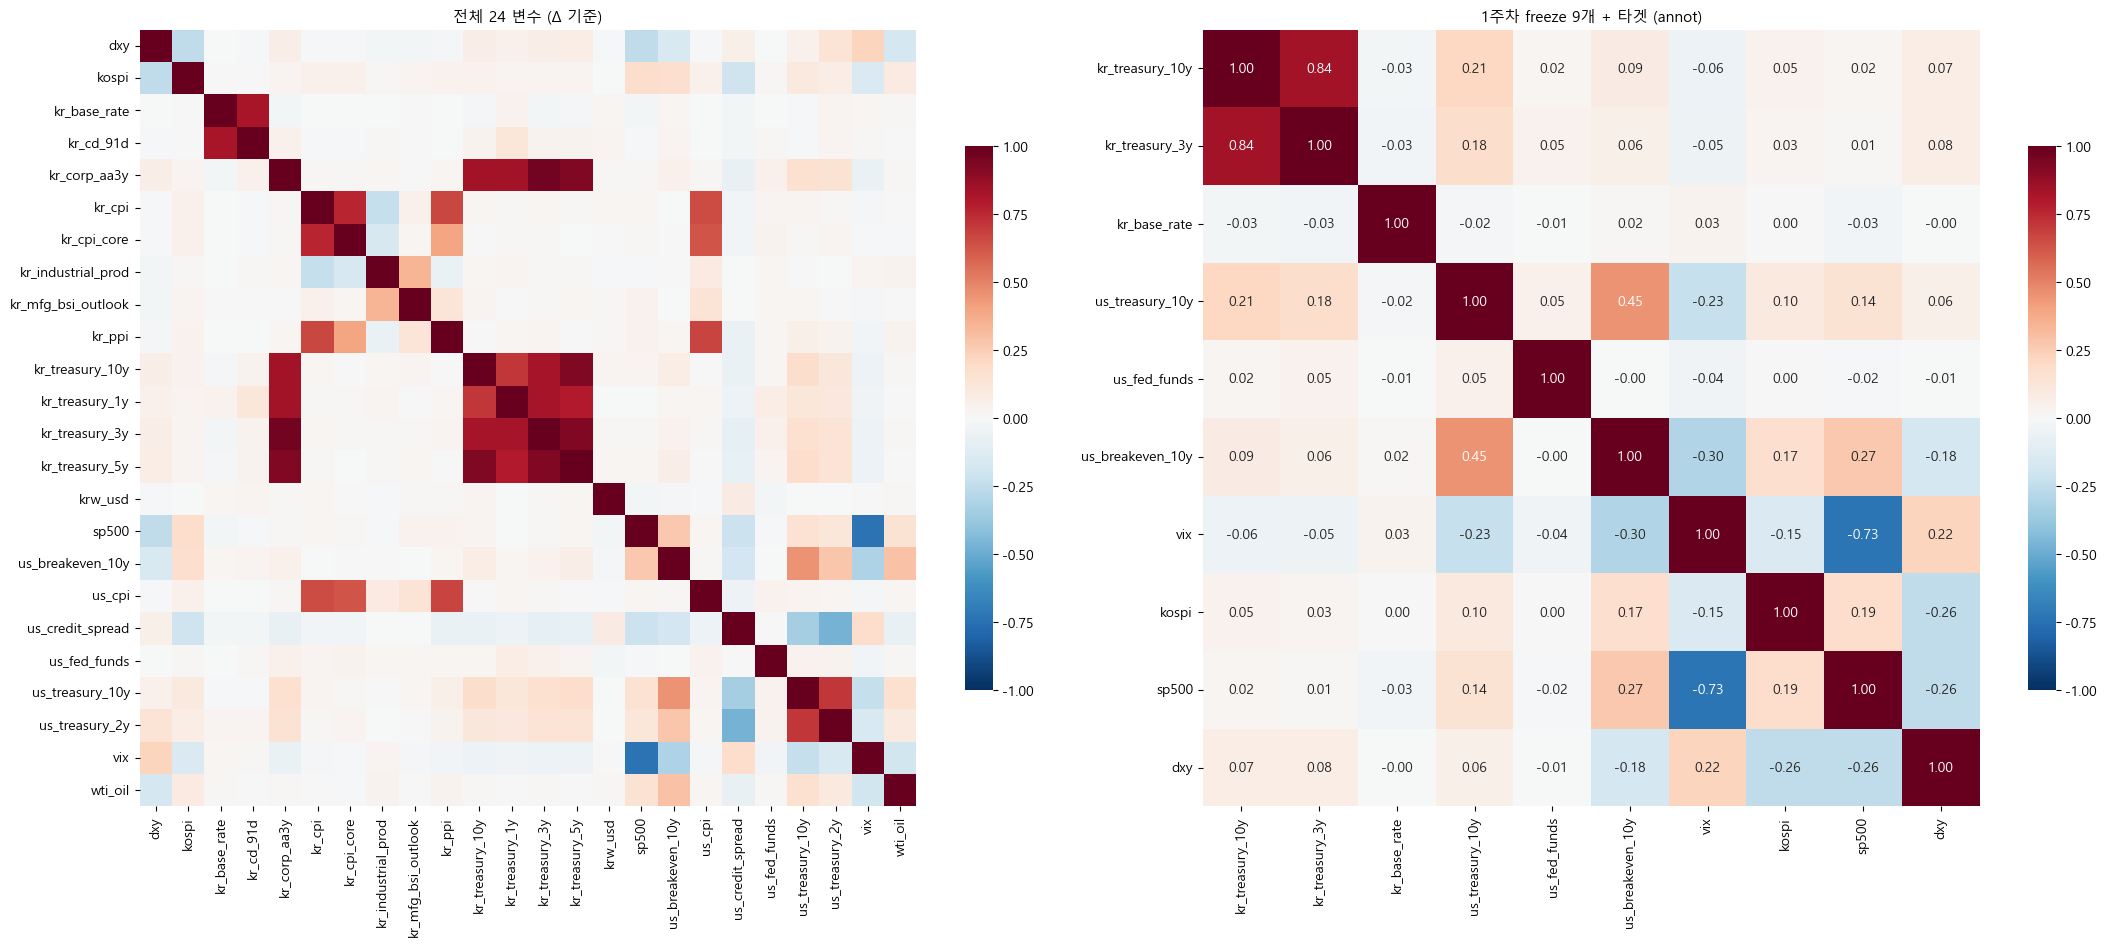


📊 9개 freeze 변수 간 |r|>0.5 쌍 (다중공선성 후보):
  vix                    ↔ sp500                  r=-0.734


In [4]:
# 모든 변수의 차분
deltas_all = wide_filled.diff()
corr_all = deltas_all.corr()

deltas_freeze = features_v1.diff()
corr_freeze = deltas_freeze.corr()

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

# (1) 22 변수 전체
sns.heatmap(corr_all, annot=False, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=axes[0], cbar_kws={'shrink': 0.7}, square=True)
axes[0].set_title('전체 24 변수 (Δ 기준)', fontsize=11)

# (2) 9 freeze + 타겟
sns.heatmap(corr_freeze, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=axes[1], square=True, cbar_kws={'shrink': 0.7})
axes[1].set_title('1주차 freeze 9개 + 타겟 (annot)', fontsize=11)

plt.tight_layout()
plt.savefig(FIG_DIR / 'w2_01_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

# |r|>0.5 쌍 추출
print('\n📊 9개 freeze 변수 간 |r|>0.5 쌍 (다중공선성 후보):')
high_corr_pairs = []
for i in range(len(FREEZE_FEATURES)):
    for j in range(i+1, len(FREEZE_FEATURES)):
        c = corr_freeze.loc[FREEZE_FEATURES[i], FREEZE_FEATURES[j]]
        if abs(c) > 0.5:
            high_corr_pairs.append({'var1': FREEZE_FEATURES[i], 'var2': FREEZE_FEATURES[j], 'r': round(c, 3)})
            print(f"  {FREEZE_FEATURES[i]:22s} ↔ {FREEZE_FEATURES[j]:22s} r={c:+.3f}")
if not high_corr_pairs:
    print('  (없음 — 9개 변수 간 다중공선성 우려 작음)')

---

## 3. VIF 분석 (산출물 2/3)

### 해석
- **VIF < 5**: 정상
- **5 ≤ VIF < 10**: 주의 (다른 변수와 약한 다중공선성)
- **VIF ≥ 10**: 다중공선성 — 1개 제거 검토

### 1주차 EDA 우려
위험 변수 3개(vix, kospi, sp500) 다중공선성 가능성 — 이 셀에서 정량 확인.


=== VIF 분석 결과 ===
              변수  VIF   상태
             vix 2.28 ✅ 정상
           sp500 2.24 ✅ 정상
us_breakeven_10y 1.38 ✅ 정상
 us_treasury_10y 1.35 ✅ 정상
             dxy 1.18 ✅ 정상
           kospi 1.11 ✅ 정상
  kr_treasury_3y 1.04 ✅ 정상
    us_fed_funds 1.01 ✅ 정상
    kr_base_rate 1.00 ✅ 정상


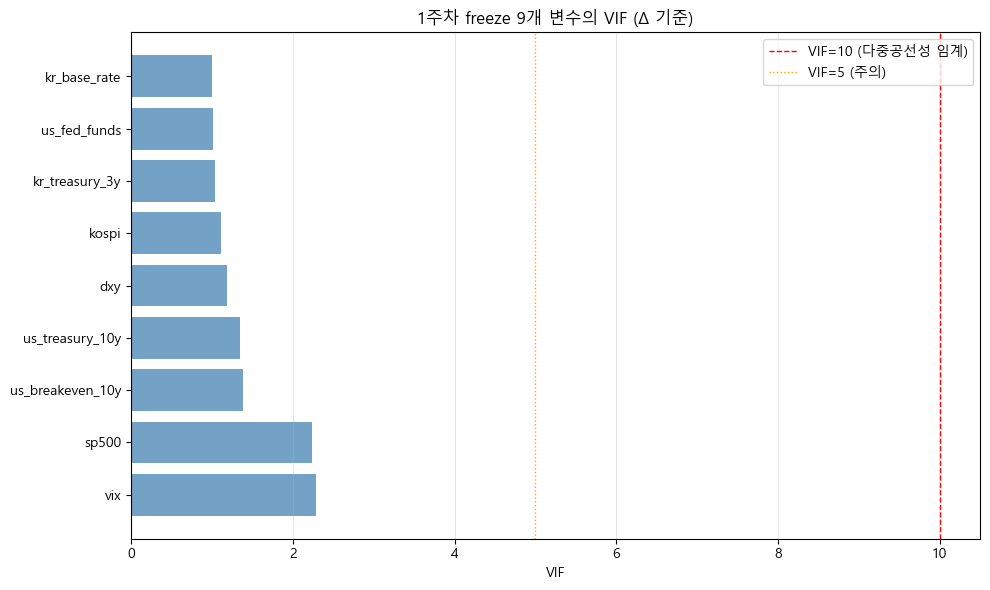


결론: 0개 변수 다중공선성 의심, 0개 변수 주의
→ 9개 freeze 다중공선성 안전 ✅


In [5]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 9 freeze 의 차분 (정상성 보장)
df_vif = features_v1[FREEZE_FEATURES].diff().dropna()

vif_data = pd.DataFrame({
    '변수': df_vif.columns,
    'VIF': [variance_inflation_factor(df_vif.values, i) for i in range(df_vif.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

def vif_flag(v):
    if v >= 10: return '🔴 다중공선성'
    elif v >= 5: return '🟠 주의'
    else: return '✅ 정상'
vif_data['상태'] = vif_data['VIF'].apply(vif_flag)
vif_data['VIF'] = vif_data['VIF'].round(2)

print('\n=== VIF 분석 결과 ===')
print(vif_data.to_string(index=False))

# 시각화
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['darkred' if v >= 10 else ('orange' if v >= 5 else 'steelblue') for v in vif_data['VIF']]
ax.barh(vif_data['변수'], vif_data['VIF'], color=colors, alpha=0.75)
ax.axvline(10, color='red', linestyle='--', linewidth=1, label='VIF=10 (다중공선성 임계)')
ax.axvline(5, color='orange', linestyle=':', linewidth=1, label='VIF=5 (주의)')
ax.set_xlabel('VIF')
ax.set_title('1주차 freeze 9개 변수의 VIF (Δ 기준)')
ax.legend()
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(FIG_DIR / 'w2_02_vif.png', dpi=120, bbox_inches='tight')
plt.show()

# 결론
n_red = (vif_data['VIF'] >= 10).sum()
n_orange = ((vif_data['VIF'] >= 5) & (vif_data['VIF'] < 10)).sum()
print(f'\n결론: {n_red}개 변수 다중공선성 의심, {n_orange}개 변수 주의')
if n_red > 0:
    print('→ §5 종합 검증에서 제거 검토')
else:
    print('→ 9개 freeze 다중공선성 안전 ✅')

---

## 4. ADF/KPSS 정상성 + Granger 인과성 (산출물 3/3)

### 단계
1. **정상성 검정**: ADF (단위근), KPSS (정상성 vs 추세)
2. 비정상이면 **차분** 후 재검정 (대부분의 거시 변수가 I(1))
3. **Granger 인과성**: 각 변수 → 타겟Δy, max lag 5
4. p < 0.05 인 변수는 "통계적으로 타겟을 선행한다"는 증거

In [6]:
from statsmodels.tsa.stattools import adfuller, kpss

def stationarity_test(series, name, after_diff=False):
    s = series.dropna()
    try:
        adf_p = adfuller(s, autolag='AIC')[1]
    except Exception:
        adf_p = np.nan
    try:
        kpss_p = kpss(s, regression='c', nlags='auto')[1]
    except Exception:
        kpss_p = np.nan
    # ADF 귀무: 단위근 있음(비정상). p<0.05 → 정상
    # KPSS 귀무: 정상. p>0.05 → 정상
    is_stationary = (adf_p < 0.05) and (kpss_p > 0.05) if not pd.isna(kpss_p) else (adf_p < 0.05)
    return {
        '변수': name + (' (Δ)' if after_diff else ''),
        'ADF p': round(adf_p, 4) if not pd.isna(adf_p) else np.nan,
        'KPSS p': round(kpss_p, 4) if not pd.isna(kpss_p) else np.nan,
        '정상성': '✅' if is_stationary else '❌'
    }

print('=== 정상성 검정 — 레벨 ===')
stat_level = []
for col in features_v1.columns:
    stat_level.append(stationarity_test(features_v1[col], col, after_diff=False))
stat_level_df = pd.DataFrame(stat_level)
print(stat_level_df.to_string(index=False))

print('\n=== 정상성 검정 — 차분 후 ===')
stat_diff = []
for col in features_v1.columns:
    stat_diff.append(stationarity_test(features_v1[col].diff(), col, after_diff=True))
stat_diff_df = pd.DataFrame(stat_diff)
print(stat_diff_df.to_string(index=False))

=== 정상성 검정 — 레벨 ===


C:\Users\dongs\AppData\Local\Temp\ipykernel_21820\1552099242.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(s, regression='c', nlags='auto')[1]
C:\Users\dongs\AppData\Local\Temp\ipykernel_21820\1552099242.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(s, regression='c', nlags='auto')[1]
C:\Users\dongs\AppData\Local\Temp\ipykernel_21820\1552099242.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(s, regression='c', nlags='auto')[1]
C:\Users\dongs\AppData\Local\Temp\ipykernel_21820\1552099242.py:10: InterpolationWarning: The test statistic is outside of the range of p-v

              변수  ADF p  KPSS p 정상성
 kr_treasury_10y 0.0880   0.010   ❌
  kr_treasury_3y 0.2315   0.010   ❌
    kr_base_rate 0.7348   0.010   ❌
 us_treasury_10y 0.5500   0.010   ❌
    us_fed_funds 0.7740   0.010   ❌
us_breakeven_10y 0.0590   0.010   ❌
             vix 0.0000   0.042   ❌
           kospi 0.9883   0.010   ❌
           sp500 0.9980   0.010   ❌
             dxy 0.6512   0.010   ❌

=== 정상성 검정 — 차분 후 ===


C:\Users\dongs\AppData\Local\Temp\ipykernel_21820\1552099242.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(s, regression='c', nlags='auto')[1]
C:\Users\dongs\AppData\Local\Temp\ipykernel_21820\1552099242.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(s, regression='c', nlags='auto')[1]
C:\Users\dongs\AppData\Local\Temp\ipykernel_21820\1552099242.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(s, regression='c', nlags='auto')[1]
C:\Users\dongs\AppData\Local\Temp\ipykernel_21820\1552099242.py:10: InterpolationWarning: The test statistic is outside of the range of p-v

                  변수  ADF p  KPSS p 정상성
 kr_treasury_10y (Δ)    0.0  0.0530   ✅
  kr_treasury_3y (Δ)    0.0  0.0667   ✅
    kr_base_rate (Δ)    0.0  0.1000   ✅
 us_treasury_10y (Δ)    0.0  0.1000   ✅
    us_fed_funds (Δ)    0.0  0.1000   ✅
us_breakeven_10y (Δ)    0.0  0.1000   ✅
             vix (Δ)    0.0  0.1000   ✅
           kospi (Δ)    0.0  0.1000   ✅
           sp500 (Δ)    0.0  0.0900   ✅
             dxy (Δ)    0.0  0.1000   ✅


C:\Users\dongs\AppData\Local\Temp\ipykernel_21820\1552099242.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(s, regression='c', nlags='auto')[1]


=== Granger 인과성 (각 변수Δ → 타겟Δy, max lag 5) ===

              변수  best_lag  p-value 유의 (p<0.05)
  kr_treasury_3y         3   0.0000           ✅
 us_treasury_10y         3   0.0000           ✅
us_breakeven_10y         1   0.0000           ✅
             dxy         1   0.0000           ✅
    kr_base_rate         5   0.0010           ✅
    us_fed_funds         5   0.0039           ✅
           sp500         5   0.0153           ✅
             vix         5   0.0539           ❌
           kospi         1   0.5705           ❌


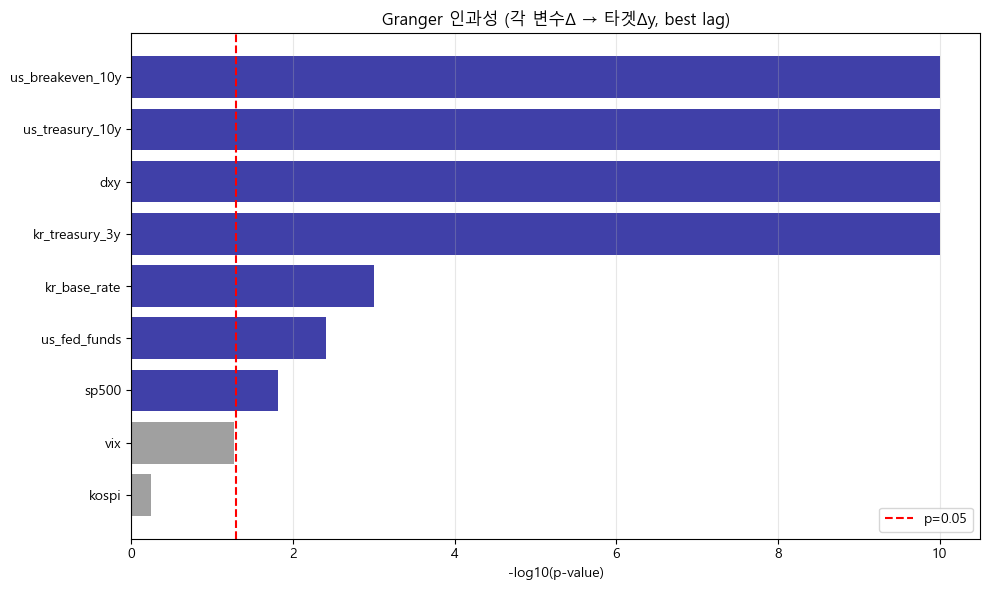


결론: 9개 freeze 중 7개가 p<0.05 로 타겟을 선행 (Granger 의미)


In [7]:
from statsmodels.tsa.stattools import grangercausalitytests

MAX_LAG = 5
target_delta = features_v1[TARGET].diff().dropna()

print(f'=== Granger 인과성 (각 변수Δ → 타겟Δy, max lag {MAX_LAG}) ===\n')
granger_results = []
for col in FREEZE_FEATURES:
    var_delta = features_v1[col].diff().dropna()
    df_g = pd.concat([target_delta, var_delta], axis=1).dropna()
    df_g.columns = ['target', 'var']
    try:
        result = grangercausalitytests(df_g, maxlag=MAX_LAG, verbose=False)
        p_by_lag = {lag: result[lag][0]['ssr_ftest'][1] for lag in range(1, MAX_LAG + 1)}
        best_lag = min(p_by_lag, key=p_by_lag.get)
        best_p = p_by_lag[best_lag]
    except Exception as e:
        best_lag, best_p = np.nan, np.nan
    granger_results.append({
        '변수': col,
        'best_lag': best_lag,
        'p-value': round(best_p, 4) if not pd.isna(best_p) else np.nan,
        '유의 (p<0.05)': '✅' if (not pd.isna(best_p) and best_p < 0.05) else '❌',
    })

granger_df = pd.DataFrame(granger_results).sort_values('p-value')
print(granger_df.to_string(index=False))

# 시각화
fig, ax = plt.subplots(figsize=(10, 6))
g_sorted = granger_df.sort_values('p-value', ascending=False)
colors = ['darkblue' if p < 0.05 else 'gray' for p in g_sorted['p-value']]
ax.barh(g_sorted['변수'], -np.log10(g_sorted['p-value'].clip(lower=1e-10)),
        color=colors, alpha=0.75)
ax.axvline(-np.log10(0.05), color='red', linestyle='--', label='p=0.05')
ax.set_xlabel('-log10(p-value)')
ax.set_title('Granger 인과성 (각 변수Δ → 타겟Δy, best lag)')
ax.legend()
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(FIG_DIR / 'w2_03_granger.png', dpi=120, bbox_inches='tight')
plt.show()

n_sig = (granger_df['p-value'] < 0.05).sum()
print(f'\n결론: 9개 freeze 중 {n_sig}개가 p<0.05 로 타겟을 선행 (Granger 의미)')

---

## 5. 종합 freeze 검증 — 9개가 데이터로 정당화되는가?

### 데이터 점수 (만점 3)
- 상관 |r| > 0.05: +1
- VIF < 10: +1
- Granger p < 0.05: +1

### 해석
- 점수 3: 강력 ✅ (모든 데이터 기준 통과)
- 점수 2: 보통 (도메인 정합성으로 채택 정당화 필요)
- 점수 1: 약함 (제거 검토)
- 점수 0: 매우 약함 (제거 권고)

In [8]:
# 종합 표 작성
summary = pd.DataFrame({'변수': FREEZE_FEATURES})
summary['상관 |r|'] = [abs(deltas_all[col].corr(target_delta)) for col in FREEZE_FEATURES]
summary = summary.merge(vif_data[['변수', 'VIF']], on='변수')
summary = summary.merge(granger_df[['변수', 'best_lag', 'p-value']], on='변수')

summary['점수'] = (
    (summary['상관 |r|'] > 0.05).astype(int) +
    (summary['VIF'] < 10).astype(int) +
    (summary['p-value'] < 0.05).astype(int)
)
summary['상관 |r|'] = summary['상관 |r|'].round(3)
summary = summary.sort_values('점수', ascending=False).reset_index(drop=True)

print('=== 9개 freeze 변수의 종합 점수 (만점 3) ===\n')
print(summary.to_string(index=False))

# 분포
print(f'\n점수 분포:')
for s in [3, 2, 1, 0]:
    n = (summary['점수'] == s).sum()
    if n > 0:
        vars_at_score = summary[summary['점수'] == s]['변수'].tolist()
        print(f'  점수 {s}: {n}개 — {vars_at_score}')

=== 9개 freeze 변수의 종합 점수 (만점 3) ===

              변수  상관 |r|  VIF  best_lag  p-value  점수
  kr_treasury_3y   0.810 1.04         3   0.0000   3
 us_treasury_10y   0.157 1.35         3   0.0000   3
us_breakeven_10y   0.066 1.38         1   0.0000   3
             dxy   0.063 1.18         1   0.0000   3
    kr_base_rate   0.016 1.00         5   0.0010   2
    us_fed_funds   0.016 1.01         5   0.0039   2
             vix   0.051 2.28         5   0.0539   2
           sp500   0.026 2.24         5   0.0153   2
           kospi   0.043 1.11         1   0.5705   1

점수 분포:
  점수 3: 4개 — ['kr_treasury_3y', 'us_treasury_10y', 'us_breakeven_10y', 'dxy']
  점수 2: 4개 — ['kr_base_rate', 'us_fed_funds', 'vix', 'sp500']
  점수 1: 1개 — ['kospi']


---

## 6. 산출물 정리 — `docs/feature_validation_w2.md`

계획서 v5.1 §3.2(a) 안전장치 — 산출물 3건 마감.

**저장 내용**:
- 상관행렬 요약 (다중공선성 후보 쌍)
- VIF 표 + 다중공선성 진단
- Granger 결과 + 유의 변수 목록
- 9개 freeze 의 종합 점수
- 3주차 ablation 대상 후보 (점수 낮은 변수)

In [9]:
# 마크다운 보고서 생성
md_path = DOCS_DIR / 'feature_validation_w2.md'
lines = []
lines.append('# 2주차 변수 검증 결과 — 1주차 freeze 9개의 데이터 정당화')
lines.append('')
lines.append(f'> 계획서 v5.1 §3.2(a) 안전장치 — 산출물 3건 사전 마감')
lines.append('> 생성: notebooks/02_feature_selection.ipynb')
lines.append('')
lines.append('## 1. 상관 분석 (다중공선성 후보)')
lines.append('')
if high_corr_pairs:
    lines.append('| 변수 1 | 변수 2 | r |')
    lines.append('|--------|--------|------|')
    for pair in high_corr_pairs:
        lines.append(f"| {pair['var1']} | {pair['var2']} | {pair['r']:+.3f} |")
else:
    lines.append('|r| > 0.5 인 9 freeze 쌍 없음 → 다중공선성 우려 작음')
lines.append('')

lines.append('## 2. VIF 분석')
lines.append('')
lines.append('| 변수 | VIF | 상태 |')
lines.append('|------|-----|------|')
for _, row in vif_data.iterrows():
    lines.append(f"| {row['변수']} | {row['VIF']} | {row['상태']} |")
lines.append('')
lines.append(f'결론: {n_red}개 다중공선성 의심, {n_orange}개 주의.')
lines.append('')

lines.append('## 3. Granger 인과성 (max lag 5)')
lines.append('')
lines.append('| 변수 | best_lag | p-value | 유의 |')
lines.append('|------|----------|---------|------|')
for _, row in granger_df.iterrows():
    lines.append(f"| {row['변수']} | {row['best_lag']} | {row['p-value']} | {row['유의 (p<0.05)']} |")
lines.append('')
lines.append(f'결론: {n_sig}개 변수가 p<0.05 로 타겟을 선행.')
lines.append('')

lines.append('## 4. 종합 점수 (만점 3)')
lines.append('')
lines.append('| 변수 | 상관 \\|r\\| | VIF | best_lag | Granger p | 점수 |')
lines.append('|------|----------|-----|----------|-----------|------|')
for _, row in summary.iterrows():
    lines.append(f"| {row['변수']} | {row['상관 |r|']} | {row['VIF']} | {row['best_lag']} | {row['p-value']} | {row['점수']} |")
lines.append('')

lines.append('## 5. 3주차 freeze 확정 권고')
lines.append('')
score_3 = summary[summary['점수'] == 3]['변수'].tolist()
score_low = summary[summary['점수'] <= 1]['변수'].tolist()
lines.append(f'- **점수 3 (강력 채택)**: {len(score_3)}개 — `{"`, `".join(score_3)}`')
lines.append(f'- **점수 1 이하 (제거 검토)**: {len(score_low)}개 — `{"`, `".join(score_low)}`' if score_low else '- **점수 1 이하**: 없음 — 9개 모두 데이터 정당화 OK ✅')
lines.append('')
lines.append('## 6. 5주차 ablation 대상 사전 명시 후보')
lines.append('')
lines.append('- 환율 ablation 1개 필수 (계획서 §3.2(b))')
if score_low:
    lines.append(f'- 추가 ablation 후보: 점수 낮은 변수 → `{"`, `".join(score_low)}`')
lines.append('')

with open(md_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(lines))
print(f'💾 저장: {md_path.relative_to(PROJECT_ROOT)}')
print(f'   라인 수: {len(lines)}')

💾 저장: docs\feature_validation_w2.md
   라인 수: 67


---

## 7. 다음 단계

### 즉시 (2주차 b) — `02b_preprocess_baseline.ipynb`

본 노트북의 산출물 3건이 끝나면 같은 주차 내에서 다음을 수행:

1. **전처리 파이프라인** (정책 변수 t-1, Lag/Rolling, Robust Scaler train-fit)
2. **Naive 베이스라인** (Δŷ = 0) — RMSE 측정
3. **ARIMA 베이스라인** (자기상관 학습 능력)
4. **누수 차단 코드 리뷰** (체크리스트 7개 자동 검증)
5. **리포트 템플릿 골격** (`reports/report_skeleton.md`)

### 3주차 — `03_freeze_xgboost.ipynb`

1. **🔴 변수 freeze 최종 확정** (금) + 사유 문서화
2. **5주차 ablation 대상 사전 명시** (환율 1개 필수 + 추가 후보)
3. **XGBoost 분위수 회귀** (`reg:quantileerror`, q=[0.05, 0.5, 0.95])

### TODO

- [ ] 본 노트북 §3 VIF 결과 → `VALIDATION_LOG.md` #31 기록
- [ ] 본 노트북 §4 Granger 유의 변수 → `VALIDATION_LOG.md` #32
- [ ] §6 산출물 표 (3건) → 발표 자료에 활용
- [ ] 점수 1 이하 변수 있으면 `data/processed/features_v2_candidate.csv` 로 저장 (제거안)
- [ ] **`02b_preprocess_baseline.ipynb` 실행** — 본 노트북의 `summary` 표 활용